In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [104]:
# =========================================================
# CONFIG
# =========================================================

START = "2018-01-01"
END   = "2025-12-31"

# USD major forex pairs
TICKERS = {
    "EURUSD": "EURUSD=X",
    "GBPUSD": "GBPUSD=X",
    "USDJPY": "USDJPY=X"
}

# --- Signals ---
TOP_K_BULL = 3              # top K pairs in bull regime
TOP_WEIGHT_BULL = 0.75      # allocate 75% to top-K names
EXIT_HOLD_DAYS = 8          # hysteresis exit
SHORT_MA = 20
LONG_MA = 60

# --- Regime ---
MA_BULL = 200               # bull regime if synthetic USD basket > MA

# --- Vol targeting ---
VOL_LB = 30
TARGET_VOL_BULL = 0.18
TARGET_VOL_BEAR = 0.10
LEV_CAP_BULL = 2.0
LEV_CAP_BEAR = 1.2

# --- Costs ---
TCOST_BPS = 2.0             # 2 bps one-way turnover cost

# --- Benchmark ---
BENCHMARK = "EURUSD"

In [105]:
# =========================================================
# Helpers
# =========================================================

def load_fx_prices(tickers: dict, start: str, end: str) -> pd.DataFrame:
    """
    Download forex close prices from Yahoo Finance.
    Returns a DataFrame with columns renamed to clean pair names.
    """
    raw = yf.download(
        list(tickers.values()),
        start=start,
        end=end,
        auto_adjust=False,
        progress=False
    )

    if raw.empty:
        raise ValueError("No data downloaded. Check internet or ticker symbols.")

    # Prefer Adj Close if available, otherwise Close
    if isinstance(raw.columns, pd.MultiIndex):
        if "Adj Close" in raw.columns.get_level_values(0):
            px = raw["Adj Close"].copy()
        else:
            px = raw["Close"].copy()
    else:
        px = raw.copy()

    reverse_map = {v: k for k, v in tickers.items()}
    px = px.rename(columns=reverse_map)

    px = px.sort_index().ffill().dropna(how="all")
    px = px.loc[start:end]

    # keep only requested columns in fixed order
    px = px[[k for k in tickers.keys() if k in px.columns]]

    if px.empty:
        raise ValueError("Price table is empty after cleaning.")

    return px

In [106]:
def compute_raw_returns(prices: pd.DataFrame) -> pd.DataFrame:
    return prices.pct_change().fillna(0.0)


def usd_aligned_returns(returns: pd.DataFrame) -> pd.DataFrame:
    """
    Convert returns into USD-strength-aligned returns:
    - For XXXUSD pairs: rising price means USD weaker -> multiply by -1
    - For USDXXX pairs: rising price means USD stronger -> keep +1
    """
    aligned = returns.copy()

    for col in aligned.columns:
        if col.endswith("USD"):      # EURUSD, GBPUSD, AUDUSD, NZDUSD
            aligned[col] = -aligned[col]
        elif col.startswith("USD"):  # USDJPY, USDCAD, USDCHF
            aligned[col] = aligned[col]
        else:
            raise ValueError(f"Unexpected pair format: {col}")

    return aligned

In [107]:
def compute_regime_from_usd_basket(prices: pd.DataFrame, ma_bull: int = 200):
    """
    Build a synthetic USD basket using USD-aligned average returns.
    Bull regime: synthetic USD basket > moving average
    """
    raw_rets = compute_raw_returns(prices)
    aligned_rets = usd_aligned_returns(raw_rets)

    basket_ret = aligned_rets.mean(axis=1)
    basket_idx = (1 + basket_ret).cumprod()

    ma = basket_idx.rolling(ma_bull).mean()
    bull = (basket_idx > ma).fillna(False)

    return bull, basket_idx, ma

In [108]:
def ma_signal(prices: pd.DataFrame, short_lb: int = 20, long_lb: int = 60) -> pd.DataFrame:
    """
    Moving-average time-series momentum signal:
    short MA > long MA -> +1
    short MA < long MA -> -1
    otherwise 0
    """
    ma_short = prices.rolling(short_lb).mean()
    ma_long = prices.rolling(long_lb).mean()

    sig = pd.DataFrame(0.0, index=prices.index, columns=prices.columns)
    sig[ma_short > ma_long] = 1.0
    sig[ma_short < ma_long] = -1.0
    return sig

In [109]:
def make_bull_positions(prices: pd.DataFrame,
                        mom: pd.DataFrame,
                        top_k: int = 3,
                        top_weight: float = 0.75,
                        exit_hold_days: int = 8) -> pd.DataFrame:
    """
    Bull regime:
    - long-only
    - concentrate on top_k momentum pairs
    - hysteresis exit after consecutive negative momentum
    """
    n = prices.shape[1]
    cols = prices.columns.tolist()
    top_k = min(top_k, max(1, n - 1))

    ranks = mom.rank(axis=1, method="first", ascending=False)
    top_now = ranks <= top_k

    pos = pd.DataFrame(0.0, index=prices.index, columns=cols)
    neg_streak = pd.DataFrame(0, index=prices.index, columns=cols)

    for i, dt in enumerate(prices.index):
        if i == 0:
            continue

        prev_dt = prices.index[i - 1]

        # update negative streak
        neg_streak.loc[dt] = neg_streak.loc[prev_dt]
        today_mom = mom.loc[dt]

        for c in cols:
            if pd.notna(today_mom[c]) and today_mom[c] < 0:
                neg_streak.loc[dt, c] += 1
            else:
                neg_streak.loc[dt, c] = 0

        desired = top_now.loc[dt].copy()

        # hysteresis: keep existing long until negative streak threshold reached
        prev_pos = pos.loc[prev_dt]
        for c in cols:
            if prev_pos[c] > 0 and not desired[c]:
                if neg_streak.loc[dt, c] < exit_hold_days:
                    desired[c] = True

        selected = desired[desired].index.tolist()

        if len(selected) == 0:
            continue

        top_names = selected[:min(top_k, len(selected))]
        other_names = [x for x in selected if x not in top_names]

        w = pd.Series(0.0, index=cols)

        if len(top_names) > 0:
            w_top = top_weight / len(top_names)
            for c in top_names:
                w[c] = w_top

        if len(other_names) > 0:
            w_other_total = 1.0 - top_weight
            w_other = w_other_total / len(other_names)
            for c in other_names:
                w[c] = w_other

        if w.sum() > 0:
            w = w / w.sum()

        pos.loc[dt] = w

    return pos.fillna(0.0)

In [110]:
def make_fx_positions_from_signal(signal: pd.DataFrame) -> pd.DataFrame:
    """
    Convert signal matrix {-1,0,1} into normalized portfolio weights.
    Gross exposure = 1 when there are active positions.
    """
    gross = signal.abs().sum(axis=1).replace(0, np.nan)
    w = signal.div(gross, axis=0).fillna(0.0)
    return w

In [111]:
def vol_target_portfolio(pos: pd.DataFrame,
                         returns: pd.DataFrame,
                         vol_lb: int,
                         target_vol: float,
                         cap: float):
    """
    Portfolio-level volatility targeting using previous-day positions.
    """
    port_ret = (pos.shift(1) * returns).sum(axis=1)

    daily_target = target_vol / np.sqrt(252)
    roll_vol = port_ret.rolling(vol_lb).std()

    lev = (daily_target / roll_vol).replace([np.inf, -np.inf], np.nan)
    lev = lev.clip(lower=0.0, upper=cap).shift(1).fillna(0.0)

    scaled_ret = lev * port_ret
    return scaled_ret, lev

In [112]:
def transaction_costs(pos: pd.DataFrame, bps: float) -> pd.Series:
    if bps <= 0:
        return pd.Series(0.0, index=pos.index)

    turnover = pos.diff().abs().sum(axis=1).fillna(0.0)
    return turnover * (bps / 10000.0)

In [113]:
def perf(ret: pd.Series) -> dict:
    ret = ret.dropna()
    if len(ret) == 0:
        raise ValueError("Empty returns.")

    ann_ret = (1 + ret).prod() ** (252 / len(ret)) - 1
    ann_vol = ret.std() * np.sqrt(252)
    sharpe = (ret.mean() / ret.std()) * np.sqrt(252) if ret.std() > 0 else np.nan

    equity = (1 + ret).cumprod()
    dd = equity / equity.cummax() - 1

    win_rate = (ret > 0).mean()

    return {
        "AnnReturn": float(ann_ret),
        "AnnVol": float(ann_vol),
        "Sharpe": float(sharpe),
        "MaxDD": float(dd.min()),
        "WinRate": float(win_rate),
        "Equity": equity,
        "Drawdown": dd
    }

In [114]:
# =========================================================
# Run Backtest
# =========================================================

prices = load_fx_prices(TICKERS, START, END)
rets = compute_raw_returns(prices)

bull, basket_idx, basket_ma = compute_regime_from_usd_basket(prices, ma_bull=MA_BULL)

signal = ma_signal(prices, short_lb=SHORT_MA, long_lb=LONG_MA)
pos = make_fx_positions_from_signal(signal)

# raw portfolio return
port_ret_raw = (pos.shift(1) * rets).sum(axis=1)

# dynamic vol targeting by regime
ret_bull, lev_bull = vol_target_portfolio(pos, rets, VOL_LB, TARGET_VOL_BULL, LEV_CAP_BULL)
ret_bear, lev_bear = vol_target_portfolio(pos, rets, VOL_LB, TARGET_VOL_BEAR, LEV_CAP_BEAR)

lev = lev_bear.copy()
lev.loc[bull] = lev_bull.loc[bull]

strat_ret = lev * port_ret_raw

# transaction costs
cost = transaction_costs(pos, TCOST_BPS)
net_ret = strat_ret - cost

# benchmark
bench_ret = rets[BENCHMARK].copy()

m = perf(net_ret)
b = perf(bench_ret)

In [115]:
print("Pairs:", list(prices.columns))
print()
print("Strategy Performance:")
print(f"AnnReturn: {m['AnnReturn']:.4f}")
print(f"AnnVol:    {m['AnnVol']:.4f}")
print(f"Sharpe:    {m['Sharpe']:.4f}")
print(f"MaxDD:     {m['MaxDD']:.4f}")
print(f"WinRate:   {m['WinRate']:.4f}")

print()
print("Benchmark Performance (EURUSD Buy & Hold):")
print(f"AnnReturn: {b['AnnReturn']:.4f}")
print(f"AnnVol:    {b['AnnVol']:.4f}")
print(f"Sharpe:    {b['Sharpe']:.4f}")
print(f"MaxDD:     {b['MaxDD']:.4f}")
print(f"WinRate:   {b['WinRate']:.4f}")

Pairs: ['EURUSD', 'GBPUSD', 'USDJPY']

Strategy Performance:
AnnReturn: 0.0353
AnnVol:    0.0938
Sharpe:    0.4161
MaxDD:     -0.1320
WinRate:   0.4923

Benchmark Performance (EURUSD Buy & Hold):
AnnReturn: -0.0024
AnnVol:    0.0719
Sharpe:    0.0031
MaxDD:     -0.2329
WinRate:   0.4942


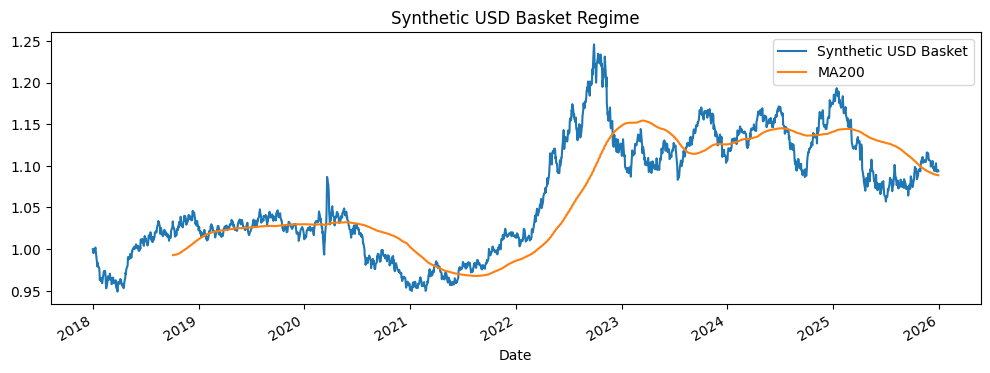

In [116]:
plt.figure(figsize=(12, 4))
basket_idx.plot(label="Synthetic USD Basket")
basket_ma.plot(label=f"MA{MA_BULL}")
plt.title("Synthetic USD Basket Regime")
plt.legend()
plt.show()

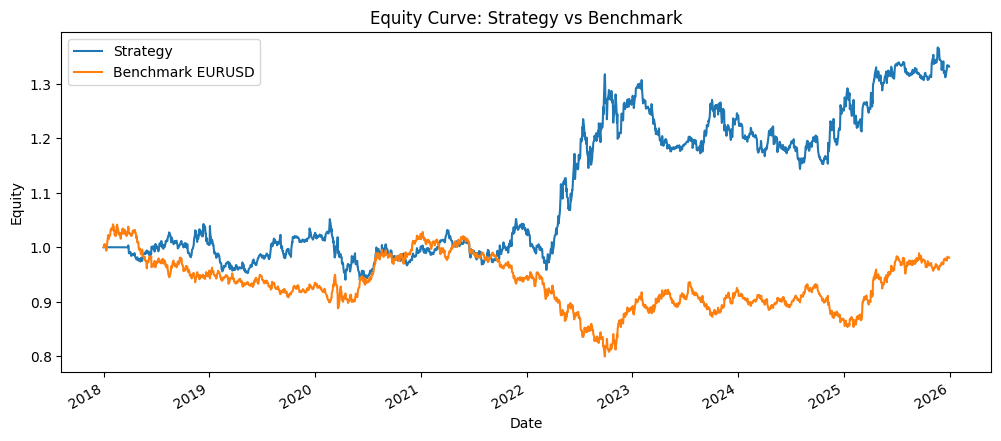

In [117]:
plt.figure(figsize=(12, 5))
m["Equity"].plot(label="Strategy")
b["Equity"].plot(label="Benchmark EURUSD")
plt.title("Equity Curve: Strategy vs Benchmark")
plt.ylabel("Equity")
plt.legend()
plt.show()

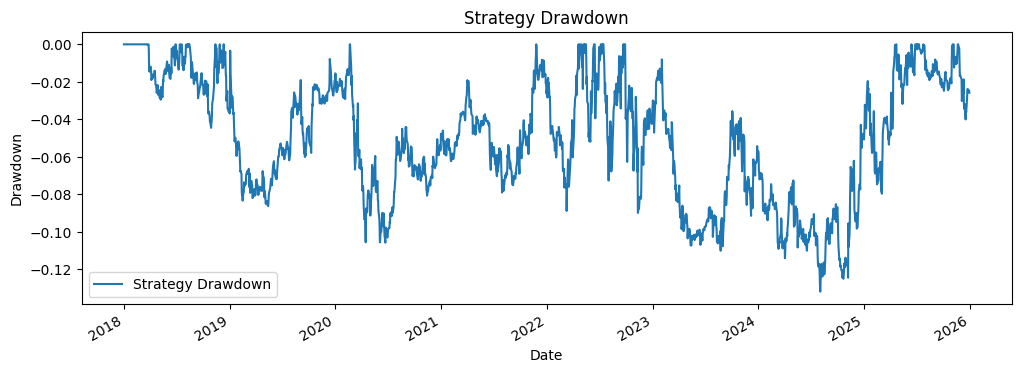

In [118]:
plt.figure(figsize=(12, 4))
m["Drawdown"].plot(label="Strategy Drawdown")
plt.title("Strategy Drawdown")
plt.ylabel("Drawdown")
plt.legend()
plt.show()

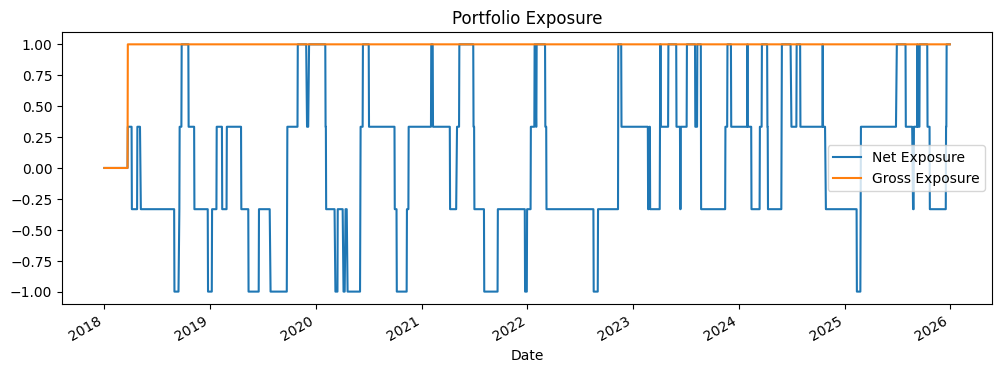

In [119]:
net_exposure = pos.sum(axis=1)
gross_exposure = pos.abs().sum(axis=1)

plt.figure(figsize=(12, 4))
net_exposure.plot(label="Net Exposure")
gross_exposure.plot(label="Gross Exposure")
plt.title("Portfolio Exposure")
plt.legend()
plt.show()

In [120]:
def split_train_test(prices: pd.DataFrame, split_ratio: float = 0.7):
    """
    Split price data into train and test by time.
    """
    n = len(prices)
    split_idx = int(n * split_ratio)

    train = prices.iloc[:split_idx].copy()
    test = prices.iloc[split_idx:].copy()

    return train, test

In [121]:
def run_backtest(prices: pd.DataFrame,
                 benchmark: str,
                 ma_bull: int,
                 short_ma: int,
                 long_ma: int,
                 vol_lb: int,
                 target_vol_bull: float,
                 target_vol_bear: float,
                 lev_cap_bull: float,
                 lev_cap_bear: float,
                 tcost_bps: float):
    """
    Run full backtest on a given price DataFrame.
    Returns metrics and intermediate objects.
    """
    rets = compute_raw_returns(prices)

    bull, basket_idx, basket_ma = compute_regime_from_usd_basket(prices, ma_bull=ma_bull)
    signal = ma_signal(prices, short_lb=short_ma, long_lb=long_ma)
    pos = make_fx_positions_from_signal(signal)

    port_ret_raw = (pos.shift(1) * rets).sum(axis=1)

    _, lev_bull = vol_target_portfolio(pos, rets, vol_lb, target_vol_bull, lev_cap_bull)
    _, lev_bear = vol_target_portfolio(pos, rets, vol_lb, target_vol_bear, lev_cap_bear)

    lev = lev_bear.copy()
    lev.loc[bull] = lev_bull.loc[bull]

    strat_ret = lev * port_ret_raw
    cost = transaction_costs(pos, tcost_bps)
    net_ret = strat_ret - cost

    bench_ret = rets[benchmark].copy()

    strat_perf = perf(net_ret)
    bench_perf = perf(bench_ret)

    return {
        "prices": prices,
        "rets": rets,
        "bull": bull,
        "basket_idx": basket_idx,
        "basket_ma": basket_ma,
        "signal": signal,
        "pos": pos,
        "lev": lev,
        "strategy_ret": net_ret,
        "benchmark_ret": bench_ret,
        "strategy_perf": strat_perf,
        "benchmark_perf": bench_perf
    }

In [122]:
# =========================================================
# Train / Test Backtest
# =========================================================

prices = load_fx_prices(TICKERS, START, END)

train_prices, test_prices = split_train_test(prices, split_ratio=0.7)

train_res = run_backtest(
    prices=train_prices,
    benchmark=BENCHMARK,
    ma_bull=MA_BULL,
    short_ma=SHORT_MA,
    long_ma=LONG_MA,
    vol_lb=VOL_LB,
    target_vol_bull=TARGET_VOL_BULL,
    target_vol_bear=TARGET_VOL_BEAR,
    lev_cap_bull=LEV_CAP_BULL,
    lev_cap_bear=LEV_CAP_BEAR,
    tcost_bps=TCOST_BPS
)

test_res = run_backtest(
    prices=test_prices,
    benchmark=BENCHMARK,
    ma_bull=MA_BULL,
    short_ma=SHORT_MA,
    long_ma=LONG_MA,
    vol_lb=VOL_LB,
    target_vol_bull=TARGET_VOL_BULL,
    target_vol_bear=TARGET_VOL_BEAR,
    lev_cap_bull=LEV_CAP_BULL,
    lev_cap_bear=LEV_CAP_BEAR,
    tcost_bps=TCOST_BPS
)

In [123]:
summary = pd.DataFrame({
    "Train_Strategy": {
        "AnnReturn": train_res["strategy_perf"]["AnnReturn"],
        "AnnVol": train_res["strategy_perf"]["AnnVol"],
        "Sharpe": train_res["strategy_perf"]["Sharpe"],
        "MaxDD": train_res["strategy_perf"]["MaxDD"],
        "WinRate": train_res["strategy_perf"]["WinRate"],
    },
    "Train_Benchmark": {
        "AnnReturn": train_res["benchmark_perf"]["AnnReturn"],
        "AnnVol": train_res["benchmark_perf"]["AnnVol"],
        "Sharpe": train_res["benchmark_perf"]["Sharpe"],
        "MaxDD": train_res["benchmark_perf"]["MaxDD"],
        "WinRate": train_res["benchmark_perf"]["WinRate"],
    },
    "Test_Strategy": {
        "AnnReturn": test_res["strategy_perf"]["AnnReturn"],
        "AnnVol": test_res["strategy_perf"]["AnnVol"],
        "Sharpe": test_res["strategy_perf"]["Sharpe"],
        "MaxDD": test_res["strategy_perf"]["MaxDD"],
        "WinRate": test_res["strategy_perf"]["WinRate"],
    },
    "Test_Benchmark": {
        "AnnReturn": test_res["benchmark_perf"]["AnnReturn"],
        "AnnVol": test_res["benchmark_perf"]["AnnVol"],
        "Sharpe": test_res["benchmark_perf"]["Sharpe"],
        "MaxDD": test_res["benchmark_perf"]["MaxDD"],
        "WinRate": test_res["benchmark_perf"]["WinRate"],
    }
})

summary

,Train_Strategy,Train_Benchmark,Test_Strategy,Test_Benchmark
AnnReturn,0.031639,-0.014885,0.030831,0.029868
AnnVol,0.093453,0.072786,0.082888,0.069672
Sharpe,0.379983,-0.169645,0.407668,0.457177
MaxDD,-0.107375,-0.232919,-0.076436,-0.084599
WinRate,0.490048,0.499657,0.449600,0.481600


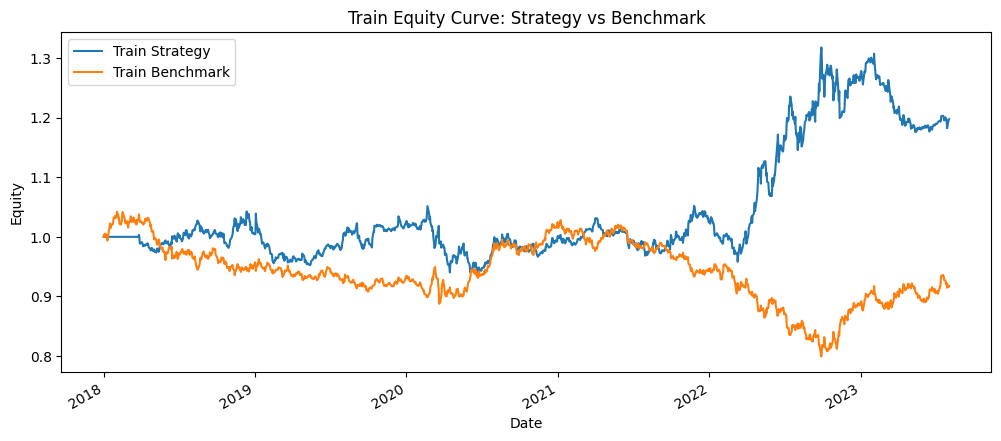

In [124]:
plt.figure(figsize=(12, 5))
train_res["strategy_perf"]["Equity"].plot(label="Train Strategy")
train_res["benchmark_perf"]["Equity"].plot(label="Train Benchmark")
plt.title("Train Equity Curve: Strategy vs Benchmark")
plt.ylabel("Equity")
plt.legend()
plt.show()

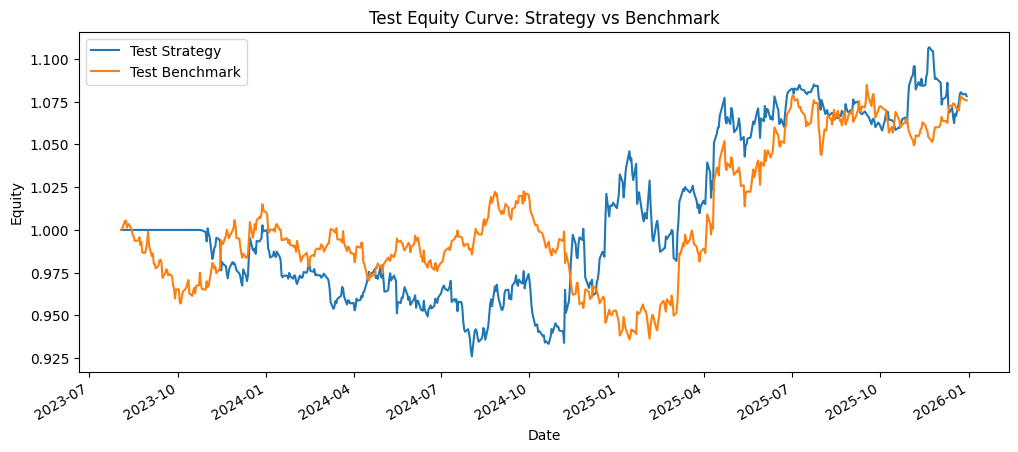

In [125]:
plt.figure(figsize=(12, 5))
test_res["strategy_perf"]["Equity"].plot(label="Test Strategy")
test_res["benchmark_perf"]["Equity"].plot(label="Test Benchmark")
plt.title("Test Equity Curve: Strategy vs Benchmark")
plt.ylabel("Equity")
plt.legend()
plt.show()